### Imports

In [1]:
from guppylang import guppy
from guppylang.std.builtins import owned, result, array
from guppylang.std.quantum import cx, h, measure, qubit, x, z, measure_array

from hugr.qsystem.result import QsysResult
from selene_sim import DepolarizingErrorModel
from selene_sim import build, Quest, Stim

import matplotlib.pyplot as plt
import numpy as np

import datetime

def timestamp():
    return datetime.datetime.now().strftime("%Y_%m_%d-%H-%M-%S")

### **Example Guppy Program:** Constructing a Bell Pair

Guppy documentation: https://docs.quantinuum.com/guppy/

In [2]:
@guppy
def bell_pair() -> array[qubit, 2]:
    qubits= array(qubit() for _ in range(2))

    h(qubits[0])
    cx(qubits[0], qubits[1])

    return qubits


@guppy
def main() -> None:
    qubits = bell_pair()
    ms = measure_array(qubits)

    result("measurements", ms)


### Compile into HUGR and simulate with Selene

Selene documentation: https://docs.quantinuum.com/selene/

In [3]:
compiled_hugr = main.compile()

runner = build(compiled_hugr)

error_model = DepolarizingErrorModel(
    p_init=1e-3,
    p_meas=1e-3,
    p_1q=1e-5,
    p_2q=1e-6,
)

result = QsysResult(runner.run_shots(
    simulator=Stim(),
    error_model=error_model,
    n_qubits=10,
    n_shots=1000,
    n_processes=4,
))

emulated_counts = result.collated_counts()

print(emulated_counts)

Counter({(('measurements', '00'),): 504, (('measurements', '11'),): 495, (('measurements', '01'),): 1})


### Plot Histogram with Matplotlib

In [4]:
def plot_collated_counts(counts):
    simplified_counts = {key[0][1]: value for key, value in counts.items()}
    simplified_counts = dict(sorted(simplified_counts.items()))
    
    fig, ax = plt.subplots(1, 1)
    possible_outcomes = simplified_counts.keys()
    idx = np.asarray(list(range(len(possible_outcomes))))

    bars = ax.bar(idx, simplified_counts.values())
    ax.bar_label(bars, labels=simplified_counts.values())

    # ax.set_title("")
    ax.set_xlabel("Measurement outcomes")
    ax.set_xticks(idx)
    ax.set_xticklabels(possible_outcomes)
    ax.set_ylabel("Counts")
    plt.show()

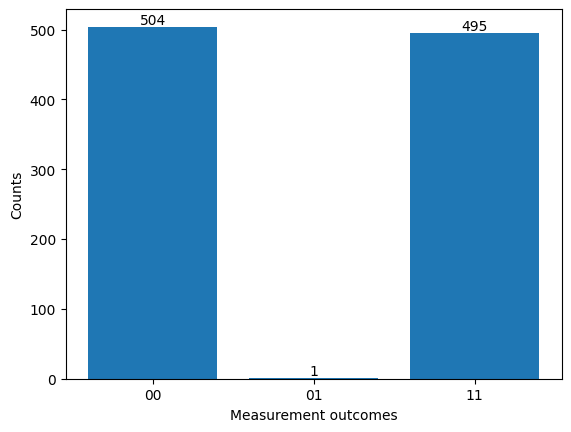

In [5]:
plot_collated_counts(emulated_counts)

### Upload and Run on Nexus

Nexus Documentation: https://docs.quantinuum.com/nexus/index.html

In [6]:
import qnexus as qnx
qnx.login()

Already logged in. Tokens are valid.


In [7]:
project = qnx.projects.get(name="Test")
qnx.context.set_active_project(project)

In [8]:
ref_hugr = qnx.hugr.upload(compiled_hugr, name=f"test-{timestamp()}" )

In [9]:
prediction = qnx.hugr.cost_confidence(programs=[ref_hugr], n_shots=[1000],system_name="Helios-1")

print(prediction)

[(12.0, 95.0)]


In [10]:
# execute_job_ref = qnx.start_execute_job(
#     programs=[ref_hugr],
#     name=f"test_execute_async",
#     n_shots=[1000],
#     n_qubits=2,
#     max_cost=[prediction[0][0]],
#     backend_config=qnx.QuantinuumConfig(device_name="Helios-1"),
# )

execute_job_ref = qnx.jobs.get(id="279c198f-3b06-4da2-a10a-2fff2d17e236")

In [11]:
qnx.jobs.wait_for(execute_job_ref)
results = qnx.jobs.results(execute_job_ref)

In [12]:
results[0].download_backend_info()

Unknown OpType in BackendInfo: `RZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `Rxxyyzz`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `U1q`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `ZZ`, will omit from BackendInfo. Consider updating your pytket version.


BackendInfo(name='Helios-1 Snapshot', device_name='Helios-1', version='0.1.0', architecture=<tket::FullyConnected, nodes=98>, gate_set={OpType.Rz}, n_cl_reg=None, supports_fast_feedforward=True, supports_reset=True, supports_midcircuit_measurement=True, all_node_gate_errors=None, all_edge_gate_errors=None, all_readout_errors=None, averaged_node_gate_errors=None, averaged_edge_gate_errors=None, averaged_readout_errors=None, misc={'noise_specs': {'1q_gate_error': {'p1': 2.5e-05, 'p1_unc': 1e-06}, '2q_gate_error': {'p2': 0.00079, 'p2_unc': 2e-05}, 'crosstalk_error': {'p_crosstalk_meas': 4.8e-05, 'p_crosstalk_meas_unc': 1e-06}, 'date': '2025-11-05', 'memory_error': {'memory_error': 0.0006, 'memory_error_unc': 3e-05}, 'spam_error': {'p_meas_0': 0.0008, 'p_meas_0_unc': 0.0001, 'p_meas_1': 0.00016, 'p_meas_1_unc': 5e-05}}})

### Download and Plot Results

In [13]:
counts = results[0].download_result().collated_counts()

print(counts)

Counter({(('measurements', '00'),): 511, (('measurements', '11'),): 489})


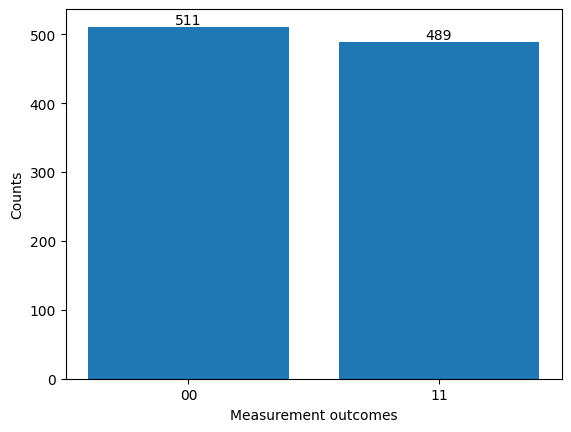

In [14]:
plot_collated_counts(counts)

In [15]:
qnx.jobs.get_all(job_status=[qnx.jobs.JobStatusEnum.COMPLETED],name_like="test_execute_async").df()

,name,description,created,modified,job_type,last_status,project,backend_config,system,cost,id
0,test_execute_async,,2026-05-04 12:30:04.254053+00:00,2026-05-04 12:30:32.213178+00:00,JobType.EXECUTE,JobStatusEnum.COMPLETED,Test,QuantinuumConfig,Helios-1E,11.60,bb78d317-3771-4279-8564-15a0fa0e091a
1,test_execute_async,,2026-05-04 12:32:30.519498+00:00,2026-05-04 12:52:14.179107+00:00,JobType.EXECUTE,JobStatusEnum.COMPLETED,Test,QuantinuumConfig,Helios-1,11.59,279c198f-3b06-4da2-a10a-2fff2d17e236


### Loading Pytket Circuits in Guppy

In [16]:
from guppylang import guppy

from pytket import Circuit
from pytket.circuit import QControlBox, Unitary1qBox
from pytket.circuit.display import render_circuit_jupyter as draw


from sympy import sqrt, Matrix

phi = (1 + sqrt(5)) / 2
f_matrix = Matrix([[1 / phi, 1 / sqrt(phi)], [1 / sqrt(phi), -1 / phi]])

pytket_circuit = Circuit(3)
pytket_circuit.add_gate(QControlBox(Unitary1qBox(np.array(f_matrix, dtype=np.complex128)), 2), [0,2,1])

draw(pytket_circuit)


### Transpiling Pytket Circuit Directly

In [17]:
from pytket.extensions.quantinuum import QuantinuumBackend, QuantinuumAPIOffline

backend = QuantinuumBackend(
    device_name="H2-1LE",
    api_handler=QuantinuumAPIOffline()
)

In [18]:
compiled_pytket_circuit = backend.get_compiled_circuit(pytket_circuit, optimisation_level=3)

draw(compiled_pytket_circuit)

In [19]:
guppy_circ = guppy.load_pytket("guppy_circ", compiled_pytket_circuit)

@guppy
def guppy_pytket_circuit() -> None:
    qubits = array(qubit() for _ in range(3))
    x(qubits[0])
    x(qubits[2])
    
    guppy_circ(qubits)

    ms = measure_array(qubits)

    result("measurements", ms)



In [20]:
compiled_pytket_hugr = guppy_pytket_circuit.compile()

runner = build(compiled_pytket_hugr)

error_model = DepolarizingErrorModel(
    p_init=1e-3,
    p_meas=1e-3,
    p_1q=1e-5,
    p_2q=1e-6,
)

result = QsysResult(runner.run_shots(
    simulator=Quest(),
    error_model=error_model,
    n_qubits=3,
    n_shots=1000,
    n_processes=4,
))

emulated_counts = result.collated_counts()

print(emulated_counts)

Counter({(('measurements', '111'),): 583, (('measurements', '101'),): 409, (('measurements', '001'),): 4, (('measurements', '011'),): 2, (('measurements', '110'),): 1, (('measurements', '100'),): 1})


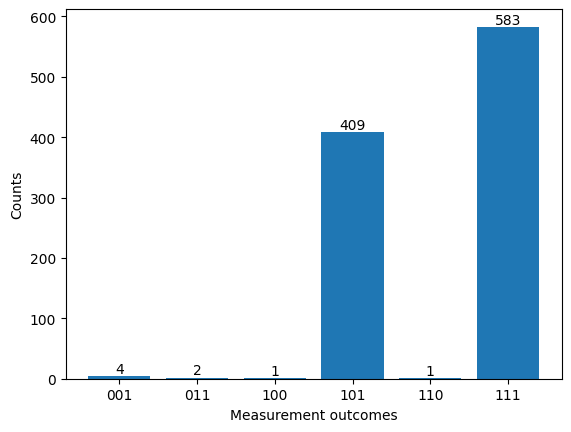

In [21]:
plot_collated_counts(emulated_counts)

In [22]:
ref_hugr_pytket = qnx.hugr.upload(compiled_pytket_hugr, name=f"test-{timestamp()}" )
pytket_prediction = qnx.hugr.cost_confidence(programs=[ref_hugr_pytket], n_shots=[1000],system_name="Helios-1")

In [23]:
print(pytket_prediction)

[(32.0, 95.0)]
